# Notebook 4: Helmet Detection Case Study

## Objective

In this notebook, we will understand a practical Computer Vision use case:

**Helmet / Hard-Hat Detection for Safety Monitoring**

We will learn:

1. How helmet detection is an object detection problem
2. How to download a pre-trained helmet / hard-hat detection model
3. How to load the downloaded model using YOLO
4. How to use either sample images or uploaded images
5. How to run helmet detection on an image
6. How to display output with bounding boxes, labels, and confidence scores
7. How this idea can be extended for industrial safety monitoring

## Case Study Idea

In industrial or construction environments, wearing a helmet or hard hat is an important safety requirement.

A Computer Vision system can analyse images, videos, or camera feed and detect whether a helmet / hard hat is visible.

## Important Note

In this training, we are not building a complete production-level gate control system.

We are creating a beginner-friendly demo to understand how Computer Vision can support safety monitoring.

For this demo, we will use a pre-trained hard-hat detection model and focus on using the model, not training it from scratch.

## Step 1: Install Required Libraries

We will install:

- `ultralytics` for YOLO object detection
- `huggingface_hub` to download the pre-trained model weights file

In [ ]:
!pip install ultralytics huggingface_hub

## Step 2: Import Required Libraries

We import the libraries required for:

- loading the YOLO model
- displaying images
- image processing
- file handling
- downloading the model file

In [ ]:
from ultralytics import YOLO
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
import cv2
import os
import zipfile

## Step 3: Download and Load the Pre-trained Model

In this step, we will download the pre-trained model weights file.

A model weights file stores the learned parameters of the trained model.

After downloading the weights file, we will load it using YOLO and use it for helmet / hard-hat detection.

In [ ]:
# Download the model file from Hugging Face
model_path = hf_hub_download(
    repo_id="keremberke/yolov8n-hard-hat-detection",
    filename="best.pt"
)

# Load the downloaded model
model = YOLO(model_path)

print("Helmet / Hard-Hat detection model loaded successfully.")
print("Model file path:", model_path)

Helmet / Hard-Hat detection model loaded successfully.
Model file path: /root/.cache/huggingface/hub/models--keremberke--yolov8n-hard-hat-detection/snapshots/287bafa2feb311ee45d21f9e9b33315ff6ff955d/best.pt


## Step 4: Check Model Classes

The loaded model can detect two classes:

1. **Hardhat** – helmet / hard hat is detected
2. **NO-Hardhat** – helmet / hard hat is not detected

During prediction, the model will display:

- Bounding box around the detected region
- Class label
- Confidence score

In [ ]:
print("Model classes:")
print(model.names)

Model classes:
{0: 'Hardhat', 1: 'NO-Hardhat'}


## Step 5: Provide a Test Image

You can use either of the following options:

### Option A: Download sample helmet images

Use this option if you do not have any local image ready.

### Option B: Upload your own image

Use this option if you already have helmet / no-helmet images stored on your computer.

For live training, keeping both options is safer.

### Option A: Download Sample Helmet Images

This downloads a small sample validation ZIP file from the hard-hat dataset repository.

If this step fails due to internet restrictions, skip it and use **Option B: Upload your own image**.

In [ ]:
# Download a small sample dataset ZIP file
!wget -O valid-mini.zip https://huggingface.co/datasets/keremberke/hard-hat-detection/resolve/main/data/valid-mini.zip

--2026-07-24 15:59:31--  https://huggingface.co/datasets/keremberke/hard-hat-detection/resolve/main/data/valid-mini.zip
Resolving huggingface.co (huggingface.co)... 3.166.152.110, 3.166.152.65, 3.166.152.44, ...
Connecting to huggingface.co (huggingface.co)|3.166.152.110|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/63c5c011addb8fa3e091357c/bfe01b211cdfc159aad5f1705bc3bb4ef63f3382b89513e35403a5b1633789ed?response-content-type=application%2Fzip&user_id=public&X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27valid-mini.zip%3B+filename%3D%22valid-mini.zip%22%3B&Expires=1784912371&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjNjNWMwMTFhZGRiOGZhM2UwOTEzNTdjL2JmZTAxYjIxMWNkZmMxNTlhYWQ1ZjE3MDViYzNiYjRlZjYzZjMzODJiODk1MTNlMzU0MDNhNWIxNjMzNzg5ZWRcXD9yZXNwb25zZS1jb250ZW50LXR5cGU9KiZ1c2VyX2lkPXB1YmxpYyZYLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1

In [ ]:
# Extract the ZIP file
extract_folder = "helmet_sample_images"

with zipfile.ZipFile("valid-mini.zip", "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Files extracted successfully.")
print("Main folder contents:")
print(os.listdir(extract_folder))

Files extracted successfully.
Main folder contents:
['_annotations.coco.json', '003984_jpg.rf.ad60765d93e67daf3a6bec9ab31ff24c.jpg', 'helmet9991207_jpg.rf.63188cfabf62f19590960cdcfe41201d.jpg', '-1990-_png_jpg.rf.a6a65555effb9a25103aed63304c5aec.jpg']


In [ ]:
# Find image files inside the extracted folder
image_files = []

for root, dirs, files in os.walk(extract_folder):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Number of images found:", len(image_files))
print("First few image files:")
print(image_files[:5])

Number of images found: 3
First few image files:
['helmet_sample_images/003984_jpg.rf.ad60765d93e67daf3a6bec9ab31ff24c.jpg', 'helmet_sample_images/helmet9991207_jpg.rf.63188cfabf62f19590960cdcfe41201d.jpg', 'helmet_sample_images/-1990-_png_jpg.rf.a6a65555effb9a25103aed63304c5aec.jpg']


In [ ]:
# Select the first sample image automatically
if len(image_files) > 0:
    test_image_path = image_files[0]
    print("Selected sample image:", test_image_path)
else:
    print("No image files found. Please use Option B to upload your own image.")

Selected sample image: helmet_sample_images/003984_jpg.rf.ad60765d93e67daf3a6bec9ab31ff24c.jpg


### Option B: Upload Your Own Test Image

Run this cell only if you want to test your own image.

After upload, copy the exact file name from the displayed file list.

In [ ]:
from google.colab import files

uploaded = files.upload()

print("Files available in current folder:")
print(os.listdir())

Saving with helmet3.jpg to with helmet3.jpg
Files available in current folder:
['.config', 'with helmet 4.jpg', 'helmet_sample_images', 'with helmet3.jpg', 'valid-mini.zip', 'helmet_detection_output.jpg', 'with helmet2.jpg', 'sample_data']


In [ ]:
# Use this cell if you uploaded your own image
# Enter the exact uploaded image file name, for example: worker1.jpg

uploaded_image_name = input("Enter uploaded image file name, or press Enter to keep sample image: ")

if uploaded_image_name.strip() != "":
    test_image_path = uploaded_image_name.strip()

print("Final selected image path:", test_image_path)

Enter uploaded image file name, or press Enter to keep sample image: with helmet 4.jpg
Final selected image path: with helmet 4.jpg


## Step 6: Display the Selected Input Image

Before running detection, we first display the selected image.

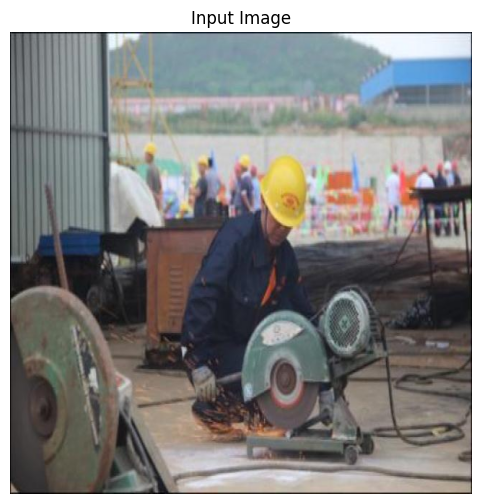

In [ ]:
# Read selected image
input_image = cv2.imread(test_image_path)

if input_image is None:
    print("Image not found. Please check the file path:", test_image_path)
else:
    # Convert BGR to RGB for correct display
    input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(input_image_rgb)
    plt.title("Input Image")
    plt.axis("off")
    plt.show()

## Step 7: Run Helmet / Hard-Hat Detection

Now we will send the selected image to the YOLO model for prediction.

In [ ]:
# Run prediction
results = model(test_image_path)

print("Helmet / Hard-Hat detection completed.")


image 1/1 /content/helmet_sample_images/003984_jpg.rf.ad60765d93e67daf3a6bec9ab31ff24c.jpg: 640x640 4 Hardhats, 212.4ms
Speed: 4.6ms preprocess, 212.4ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Helmet / Hard-Hat detection completed.


## Step 8: Display Detection Output

The output image will show:

- bounding boxes
- class labels
- confidence scores

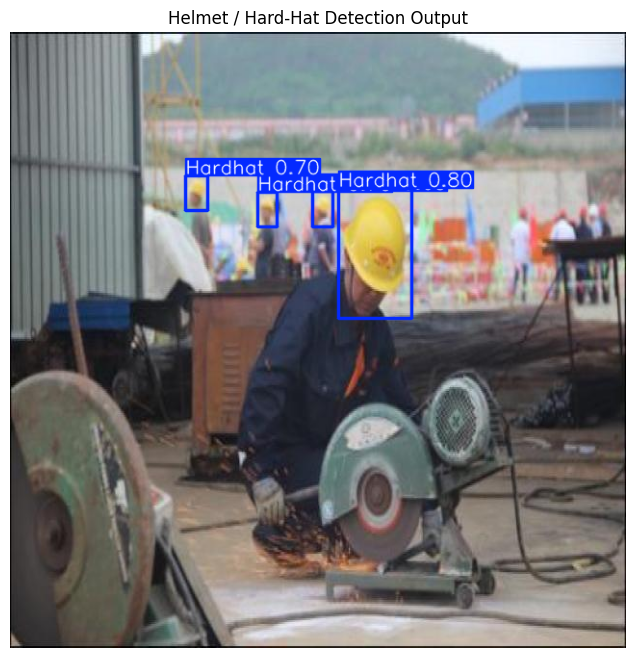

In [ ]:
# Display image with detected objects
for result in results:
    annotated_image = result.plot()

    # Convert BGR to RGB for display
    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_image_rgb)
    plt.title("Helmet / Hard-Hat Detection Output")
    plt.axis("off")
    plt.show()

## Step 9: Print Detection Details

This cell prints:

- detected class
- confidence score
- bounding box coordinates

Bounding box coordinates are:

- `x1, y1` = top-left corner
- `x2, y2` = bottom-right corner

In [ ]:
# Print detected object details
for result in results:
    boxes = result.boxes

    if len(boxes) == 0:
        print("No helmet / hard-hat related object detected.")
    else:
        for box in boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            confidence = float(box.conf[0])

            x1, y1, x2, y2 = box.xyxy[0]

            print("Detected Class:", class_name)
            print("Confidence Score:", round(confidence, 2))
            print("Bounding Box Coordinates:")
            print("x1:", round(float(x1), 2))
            print("y1:", round(float(y1), 2))
            print("x2:", round(float(x2), 2))
            print("y2:", round(float(y2), 2))
            print("-------------------------")

Detected Class: Hardhat
Confidence Score: 0.8
Bounding Box Coordinates:
x1: 341.47
y1: 162.46
x2: 417.1
y2: 297.14
-------------------------
Detected Class: Hardhat
Confidence Score: 0.7
Bounding Box Coordinates:
x1: 182.99
y1: 149.14
x2: 205.38
y2: 185.17
-------------------------
Detected Class: Hardhat
Confidence Score: 0.7
Bounding Box Coordinates:
x1: 257.86
y1: 166.67
x2: 277.42
y2: 202.53
-------------------------
Detected Class: Hardhat
Confidence Score: 0.65
Bounding Box Coordinates:
x1: 314.97
y1: 165.81
x2: 335.24
y2: 202.67
-------------------------


## Step 10: Save Detection Output Image

We will save the annotated output image so it can be used later in a report or PPT.

In [ ]:
# Save annotated detection output
for result in results:
    annotated_image = result.plot()
    cv2.imwrite("helmet_detection_output.jpg", annotated_image)

print("Detection output saved as helmet_detection_output.jpg")

Detection output saved as helmet_detection_output.jpg


In [ ]:
# Check saved output file
print("Files available in current folder:")
print(os.listdir())

Files available in current folder:
['.config', 'with helmet 4.jpg', 'helmet_sample_images', 'valid-mini.zip', 'helmet_detection_output.jpg', 'sample_data']


## Step 11: Download the Output Image

Use this step if you want to download the final detection image to your computer.

In [ ]:
from google.colab import files

files.download("helmet_detection_output.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Learner Practice Task

Try the following:

1. Test the model on another helmet / no-helmet image.
2. Observe the predicted class:
   - Hardhat
   - NO-Hardhat
3. Check the confidence score.
4. Compare results for:
   - clear image
   - blurred image
   - multiple people
   - poor lighting
5. Save the detection output.

## Expected Learning

After this activity, you should understand how a pre-trained object detection model can be used for a safety-monitoring use case.

## Practical Discussion

Computer Vision systems may give incorrect results if:

- lighting is poor
- helmet is partially visible
- person is too far from the camera
- image is blurred
- camera angle is not proper
- cap or other object looks similar to helmet

For actual deployment, the system must be tested properly using real site images and videos.